# Model Evaluation — Stock Sentiment Pipeline\n\nCompares VADER, FinBERT, and GPT/Ollama on:\n1. F1 / Accuracy / Precision / Recall on 200 human-labeled tweets\n2. Pearson correlation between sentiment score and stock returns (lags 0–3)\n3. Label distribution per model\n4. Inter-model agreement\n5. Final model selection

In [1]:
import sys, os
from pathlib import Path

# Hardcoded project root
PROJECT_ROOT = Path('/Users/ratchanon/Documents/Intania/seml/Project/Dev')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.evaluation import EvaluationEngine

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_colwidth', 80)

HUMAN_LABELS = str(PROJECT_ROOT / 'human_labels/lebeled_clean.csv')
RESULTS_DIR  = PROJECT_ROOT / 'results'
MODELS       = ['vader', 'finbert', 'gpt']

# Load available model results
results = {}
for m in MODELS:
    p = RESULTS_DIR / f'{m}_results.csv'
    if p.exists():
        results[m] = pd.read_csv(p)
        print(f'✓ {m}: {len(results[m]):,} rows')
    else:
        print(f'✗ {m}: not found — {p}')

evaluator = EvaluationEngine()

Project root: /Users/ratchanon/Documents/Intania/seml/Project/Dev
✓ vader: 9,855 rows
✓ finbert: 9,855 rows
✓ gpt: 9,855 rows


## 1. F1 / Accuracy on Human-Labeled Tweets (200 samples)

In [2]:
hl_metrics = {}

for model, df in results.items():
    if not Path(HUMAN_LABELS).exists():
        print('Human labels not found — skipping')
        break
    m = evaluator.evaluate_on_human_labels(df, HUMAN_LABELS, model)
    hl_metrics[model] = m

if hl_metrics:
    summary = pd.DataFrame(hl_metrics).T
    summary.index.name = 'model'
    display(summary.style.highlight_max(axis=0, color='#2ecc71').format('{:.4f}'))


,accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted
model,,,,,
vader,0.3450,0.2987,0.2809,0.2683,0.3450
finbert,0.2700,0.2613,0.2718,0.5073,0.2700
gpt,0.6450,0.6294,0.5871,0.6328,0.6450


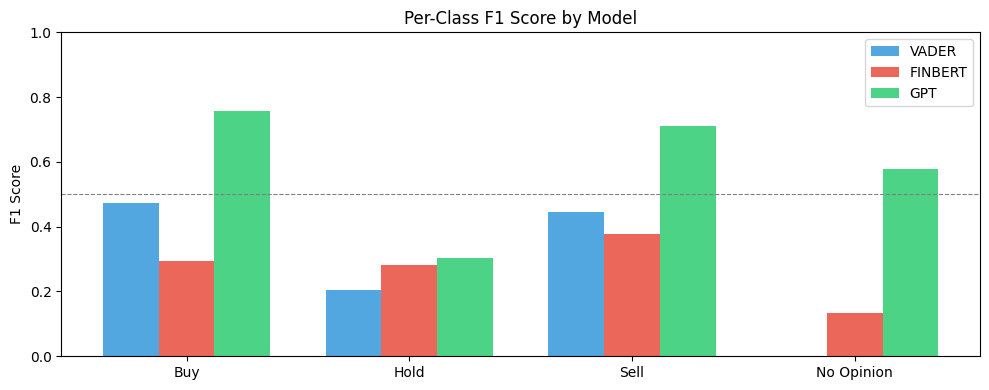

In [3]:
# Per-class F1 bar chart
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

labels_df = pd.read_csv(HUMAN_LABELS)
classes = ['Buy', 'Hold', 'Sell', 'No Opinion']
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(classes))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model, df) in enumerate(results.items()):
    merged = df.merge(labels_df[['tweet_id', 'final_label']], on='tweet_id', how='inner')
    f1s = f1_score(merged['final_label'], merged['label'],
                   labels=classes, average=None, zero_division=0)
    ax.bar(x + i * width, f1s, width, label=model.upper(), color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(classes)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Model')
ax.legend()
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='0.5 threshold')
plt.tight_layout()
plt.show()

## 2. Pearson Correlation — Sentiment vs. Next-Day Stock Return

In [4]:
corr_summary = []

for model in results:
    agg_path = RESULTS_DIR / f'aggregated_{model}.csv'
    if not agg_path.exists():
        continue
    agg = pd.read_csv(agg_path)
    corr = evaluator.evaluate_sentiment_price_correlation(agg, model, n_bootstrap=500)

    for key, val in corr.items():
        ticker, lag = key.rsplit('_lag', 1)
        corr_summary.append({
            'model': model, 'ticker': ticker, 'lag': int(lag),
            'pearson_r': val['pearson_r'], 'p_value': val['p_value'],
            'ci_lo': val['ci_95_lo'], 'ci_hi': val['ci_95_hi'], 'n': val['n']
        })

corr_df = pd.DataFrame(corr_summary)

# Highlight significant results (p < 0.05)
def highlight_sig(val):
    return 'background-color: #1a472a' if isinstance(val, float) and val < 0.05 else ''

display(
    corr_df[corr_df['ticker'] != 'combined']
    .pivot_table(index=['ticker','lag'], columns='model', values='pearson_r')
    .round(4)
    .style.background_gradient(cmap='RdYlGn', axis=None)
    .set_caption('Pearson r (sentiment → return) — green = positive correlation')
)

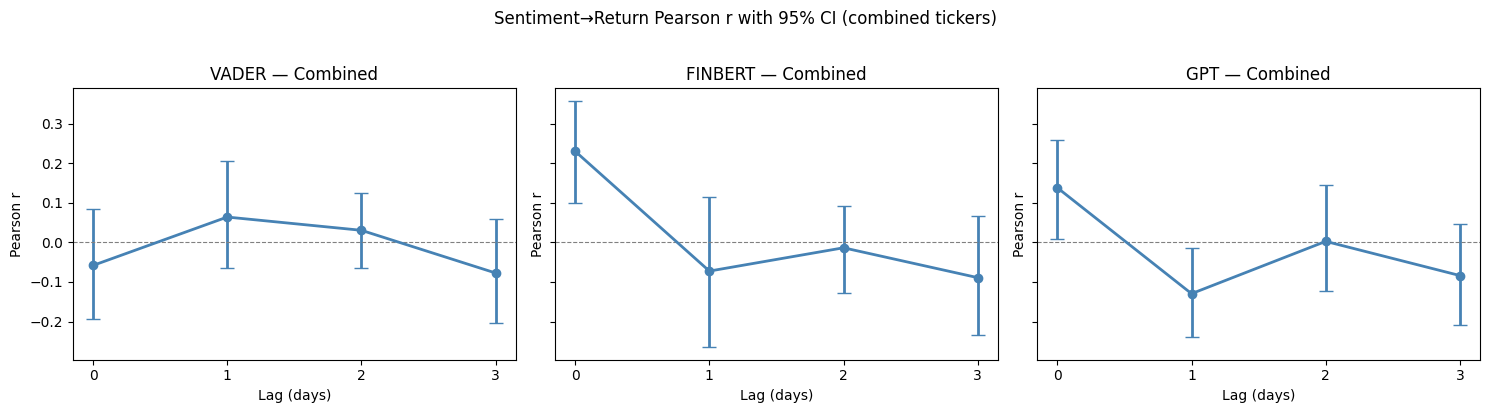

In [5]:
# Pearson r with CI — combined ticker, all lags
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, (model, _) in zip(axes, results.items()):
    sub = corr_df[(corr_df['model'] == model) & (corr_df['ticker'] == 'combined')]
    if sub.empty:
        continue
    ax.errorbar(sub['lag'], sub['pearson_r'],
                yerr=[sub['pearson_r'] - sub['ci_lo'], sub['ci_hi'] - sub['pearson_r']],
                fmt='o-', capsize=5, color='steelblue', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{model.upper()} — Combined')
    ax.set_xlabel('Lag (days)')
    ax.set_ylabel('Pearson r')
    ax.set_xticks([0, 1, 2, 3])

plt.suptitle('Sentiment→Return Pearson r with 95% CI (combined tickers)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Label Distribution per Model

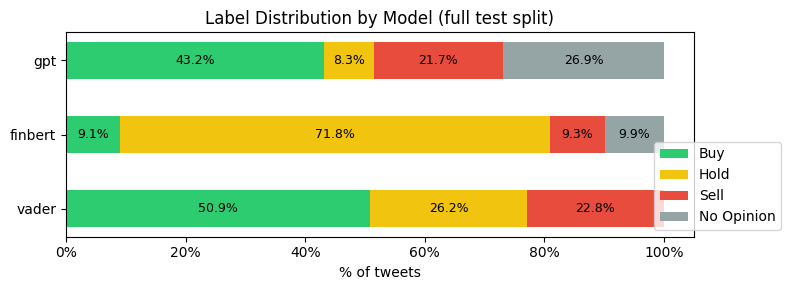

label,Buy,Hold,Sell,No Opinion
vader,50.89%,26.21%,22.82%,0.08%
finbert,9.10%,71.77%,9.25%,9.87%
gpt,43.19%,8.26%,21.66%,26.89%


In [6]:
label_order = ['Buy', 'Hold', 'Sell', 'No Opinion']
label_colors = {'Buy': '#2ecc71', 'Hold': '#f1c40f', 'Sell': '#e74c3c', 'No Opinion': '#95a5a6'}

dist_data = {}
for model, df in results.items():
    vc = df['label'].value_counts(normalize=True).reindex(label_order, fill_value=0)
    dist_data[model] = vc

dist_df = pd.DataFrame(dist_data).T * 100

fig, ax = plt.subplots(figsize=(8, 3))
bottom = np.zeros(len(dist_df))
for label in label_order:
    vals = dist_df[label].values
    bars = ax.barh(dist_df.index, vals, left=bottom,
                   color=label_colors[label], label=label, height=0.5)
    for bar, val in zip(bars, vals):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', ha='center', va='center', fontsize=9, color='black')
    bottom += vals

ax.set_xlabel('% of tweets')
ax.set_title('Label Distribution by Model (full test split)')
ax.legend(loc='lower right', bbox_to_anchor=(1.15, 0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

display(dist_df.round(2).style.background_gradient(cmap='YlOrRd', axis=1)
        .format('{:.2f}%').set_caption('Label % by model'))

## 4. Inter-Model Agreement

In [7]:
if len(results) > 1:
    names = list(results.keys())
    dfs   = [results[n] for n in names]
    agreement = evaluator.inter_model_agreement(*dfs, model_names=names)
    display(agreement.style.bar(subset=['agreement_rate'], color='#3498db')
            .format({'agreement_rate': '{:.4f}'})
            .set_caption('Inter-model agreement rate (higher = more consistent signal)'))
else:
    print('Need at least 2 models to compute agreement. Run finbert or gpt first.')

,pair,agreement_rate,n
0,vader↔finbert,0.3257,9855
1,vader↔gpt,0.3388,9855
2,finbert↔gpt,0.2031,9855


## 5. Final Model Selection

In [8]:
# Build combined metrics dict for decision table
all_metrics = {}

for model in results:
    m = {}
    # F1 from human labels
    if model in hl_metrics:
        m.update(hl_metrics[model])
    # Best Pearson r (combined, any lag)
    for _, row in corr_df[(corr_df['model'] == model) & (corr_df['ticker'] == 'combined')].iterrows():
        m[f"combined_lag{int(row['lag'])}"] = {'pearson_r': row['pearson_r']}
    # No opinion rate
    if model in results:
        vc = results[model]['label'].value_counts(normalize=True)
        m['no_opinion_rate'] = vc.get('No Opinion', 0)
    all_metrics[model] = m

best = evaluator.compare_models(all_metrics)

print('=' * 50)
print(f'  SELECTED MODEL: {best.upper()}')
print('=' * 50)
print('\nDecision table:')
decision_rows = []
for model, m in all_metrics.items():
    best_r = max((abs(v['pearson_r']) for k, v in m.items()
                  if 'combined_lag' in k and isinstance(v, dict)), default=0)
    decision_rows.append({
        'model': model,
        'f1_weighted': m.get('f1_weighted', 'N/A'),
        'best_pearson_r': round(best_r, 4),
        'no_opinion_rate': round(m.get('no_opinion_rate', 0), 4),
        'winner': '🏆' if model == best else ''
    })

display(pd.DataFrame(decision_rows).set_index('model'))

  SELECTED MODEL: GPT

Decision table:


,f1_weighted,best_pearson_r,no_opinion_rate,winner
model,,,,
vader,0.2987,0.0773,0.0008,
finbert,0.2613,0.2303,0.0987,
gpt,0.6294,0.1381,0.2689,🏆
